<h1> Epsilon Decay Greedy

In the previous notebook, we encountered a significant issue with the fixed ε-Greedy strategy (e.g., epsilon = 0.1):

Even when the agent has become fairly certain—choosing the best action 90% of the time and a random action 10% of the time—exploration continues.

This leads to:
- Regret never dropping to a minimal level
- Slight fluctuations in reward
- Unnecessary exploration during the final stages of training

#### Idea:

Instead of keeping ε constant, let's decrease it over time. That is, at the start of training:

$epsilon = 1.0$

The agent explores almost entirely, since it doesn't know anything yet.

#### Decay formula

One of the simple methods:

$\epsilon_t = \epsilon_0 \times decay^t$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from src.bandit import (
    MultiArmedBandit,
    EpsilonGreedyAgent,
    EpsilonDecayAgent,
)

<h3> Step 1: Epsilon Decay Agent Implementation

In [2]:
def run_agent(
    bandit,
    agent,
    steps=1000
):
    rewards = []
    actions = []

    for _ in range(steps):
        action = agent.select_action()
        reward = bandit.step(action)
        agent.update(
            action,
            reward
        )

        rewards.append(reward)
        actions.append(action)

    return rewards, actions

In [3]:
bandit = MultiArmedBandit(
    n_arms=10
)

agent = EpsilonDecayAgent(
    n_arms=10,
    epsilon=1,
    decay=0.995
)

rewards, actions = run_agent(
    bandit,
    agent,
    steps=5000
)

<h3> Step 2: Visualization

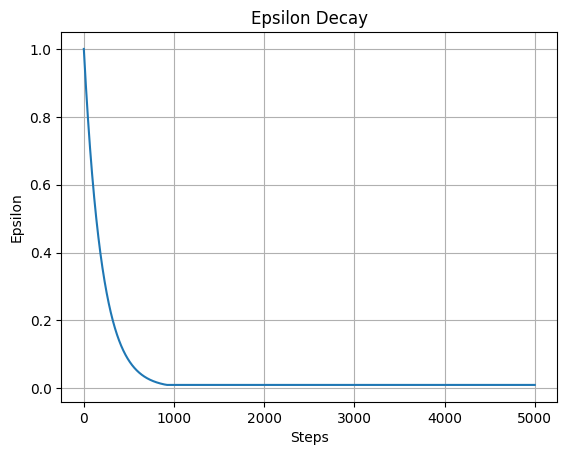

In [4]:
plt.plot(
    agent.epsilon_history
)

plt.xlabel(
    "Steps"
)

plt.ylabel(
    "Epsilon"
)

plt.title(
    "Epsilon Decay"
)

plt.grid()
plt.show()

In [5]:
len(agent.epsilon_history)

5000

### Epsilon Decay Analysis

In epsilon-decay strategy, the exploration rate is gradually reduced during training.

At the beginning of training, epsilon is high, allowing the agent to explore different actions and collect information about the environment.

As the number of steps increases, epsilon decreases exponentially until reaching the minimum value. This shifts the agent behavior from exploration to exploitation.

Compared to fixed epsilon-greedy, epsilon-decay reduces unnecessary random actions in later stages of training, allowing the agent to focus more on the best-known actions.

This provides a better balance between discovering new actions early and exploiting learned knowledge later.

<h3> Step 3: Running the experiment for epsilon decay

In [6]:
bandit = MultiArmedBandit(
    n_arms=10
)

decay_agent = EpsilonDecayAgent(
    n_arms=10,
    epsilon=1.0,
    decay=0.995,
    min_epsilon=0.01
)

decay_rewards, decay_actions = run_agent(
    bandit,
    decay_agent,
    steps=5000
)

decay_avg_reward = (
    np.cumsum(decay_rewards)
    /
    np.arange(
        1,
        len(decay_rewards)+1
    )
)

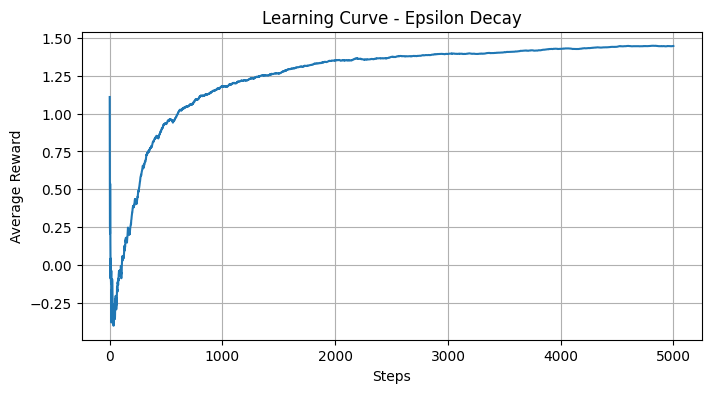

In [7]:
plt.figure(figsize=(8,4))

plt.plot(
    decay_avg_reward
)

plt.xlabel(
    "Steps"
)

plt.ylabel(
    "Average Reward"
)

plt.title(
    "Learning Curve - Epsilon Decay"
)

plt.grid()
plt.show()

In this chart, we observe that at the beginning of training, the agent engages in extensive exploration due to the high epsilon value, resulting in significant fluctuations in the average reward.
As the number of steps increases, the epsilon value decreases, and the agent relies more on the knowledge it has acquired. Consequently, the average reward gradually rises and approaches a stable level.
By the end of training, the agent has converged to the optimal action, and the average reward is close to the environment's optimal value.

<h3> Step 4: Expected Regret

We do not use the actual reward as before; instead, we convert the actions selected by the agent into the mean.

In [8]:
chosen_means = np.array([
    bandit.means[a]
    for a in decay_actions
])

decay_regret = (
    bandit.means.max()
    -
    chosen_means
)

decay_cumulative_regret = np.cumsum(
    decay_regret
)

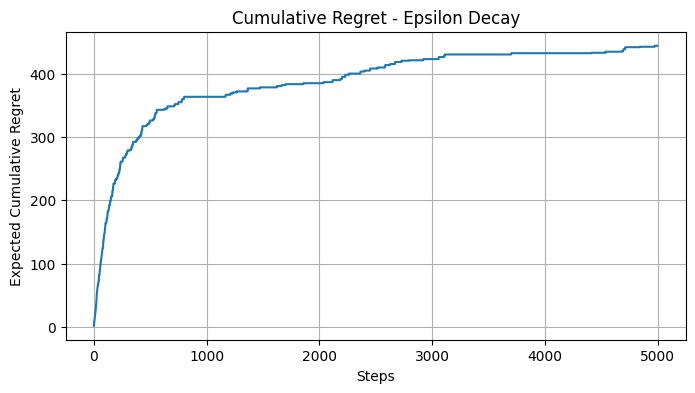

In [9]:
plt.figure(figsize=(8,4))

plt.plot(
    decay_cumulative_regret
)

plt.xlabel(
    "Steps"
)

plt.ylabel(
    "Expected Cumulative Regret"
)

plt.title(
    "Cumulative Regret - Epsilon Decay"
)

plt.grid()
plt.show()

In this graph:
- Regret rises rapidly at the beginning of the learning process.
- This is due to extensive exploration during the initial stages, as the agent lacks sufficient information about the arms.

After approximately 700 to 1,000 steps:
- The slope of the graph flattens significantly.
- This indicates that the agent selects the optimal arm most of the time.
- The increase in regret levels off.

This behavior demonstrates that the gradual reduction in exploration leads the agent to make fewer random decisions once learning has taken place.